In [2]:
import os
import gc
import csv
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torchvision.io import read_image
from torchvision import models
from torchvision.transforms import v2 as transforms
from torch.utils.data import Dataset, SubsetRandomSampler
from safetensors.torch import save_model, load_model
import torchvision.transforms.functional as F

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [4]:
class SquarePad:
    def __call__(self, image):
        c, h, w = image.size()
        max_wh = np.max([w, h])
        hp = (max_wh - w) // 2 + max_wh // 10
        vp = (max_wh - h) // 2 + max_wh // 10
        padding = (hp, vp, hp, vp)
        return F.pad(image, padding, 1, 'constant')

def image_transform(test=False):
    # normalize = transforms.Normalize(
    #     mean=[0.4914, 0.4822, 0.4465],
    #     std=[0.2023, 0.1994, 0.2010],
    # )
    mid_transforms = [
    ] if test else [
        # transforms.RandomHorizontalFlip(),
        # transforms.RandomVerticalFlip(),
        transforms.RandomAffine(degrees=10, translate=(0.1,0.1), scale=(0.9,1.1)),
        transforms.ColorJitter(),
        # transforms.GaussianBlur(5),
    ]
    return transforms.Compose([
        transforms.ConvertImageDtype(torch.float),
        transforms.RGB(),
        SquarePad(),
    ] + mid_transforms + [
        transforms.Resize((224,224)),
        # normalize,
        transforms.Lambda(lambda x: torch.clamp(x, 0, 1))
    ])


def load_image(path):
    transform = image_transform(test=True)
    image = read_image(path)
    image = transform(image)
    return image

In [5]:
def load_paths(root_dir, list_path=None) -> list:
    if list_path is None:
        filenames = next(os.walk(root_dir), (None, None, []))[2]
        return [os.path.join(root_dir, filename) for filename in filenames]
    else:
        filenames = pd.read_csv(list_path, header=None, index_col=None)
        return [os.path.join(root_dir, filename) for _, row in filenames.items() for filename in row ]

In [6]:
images_path = '../data/logos'

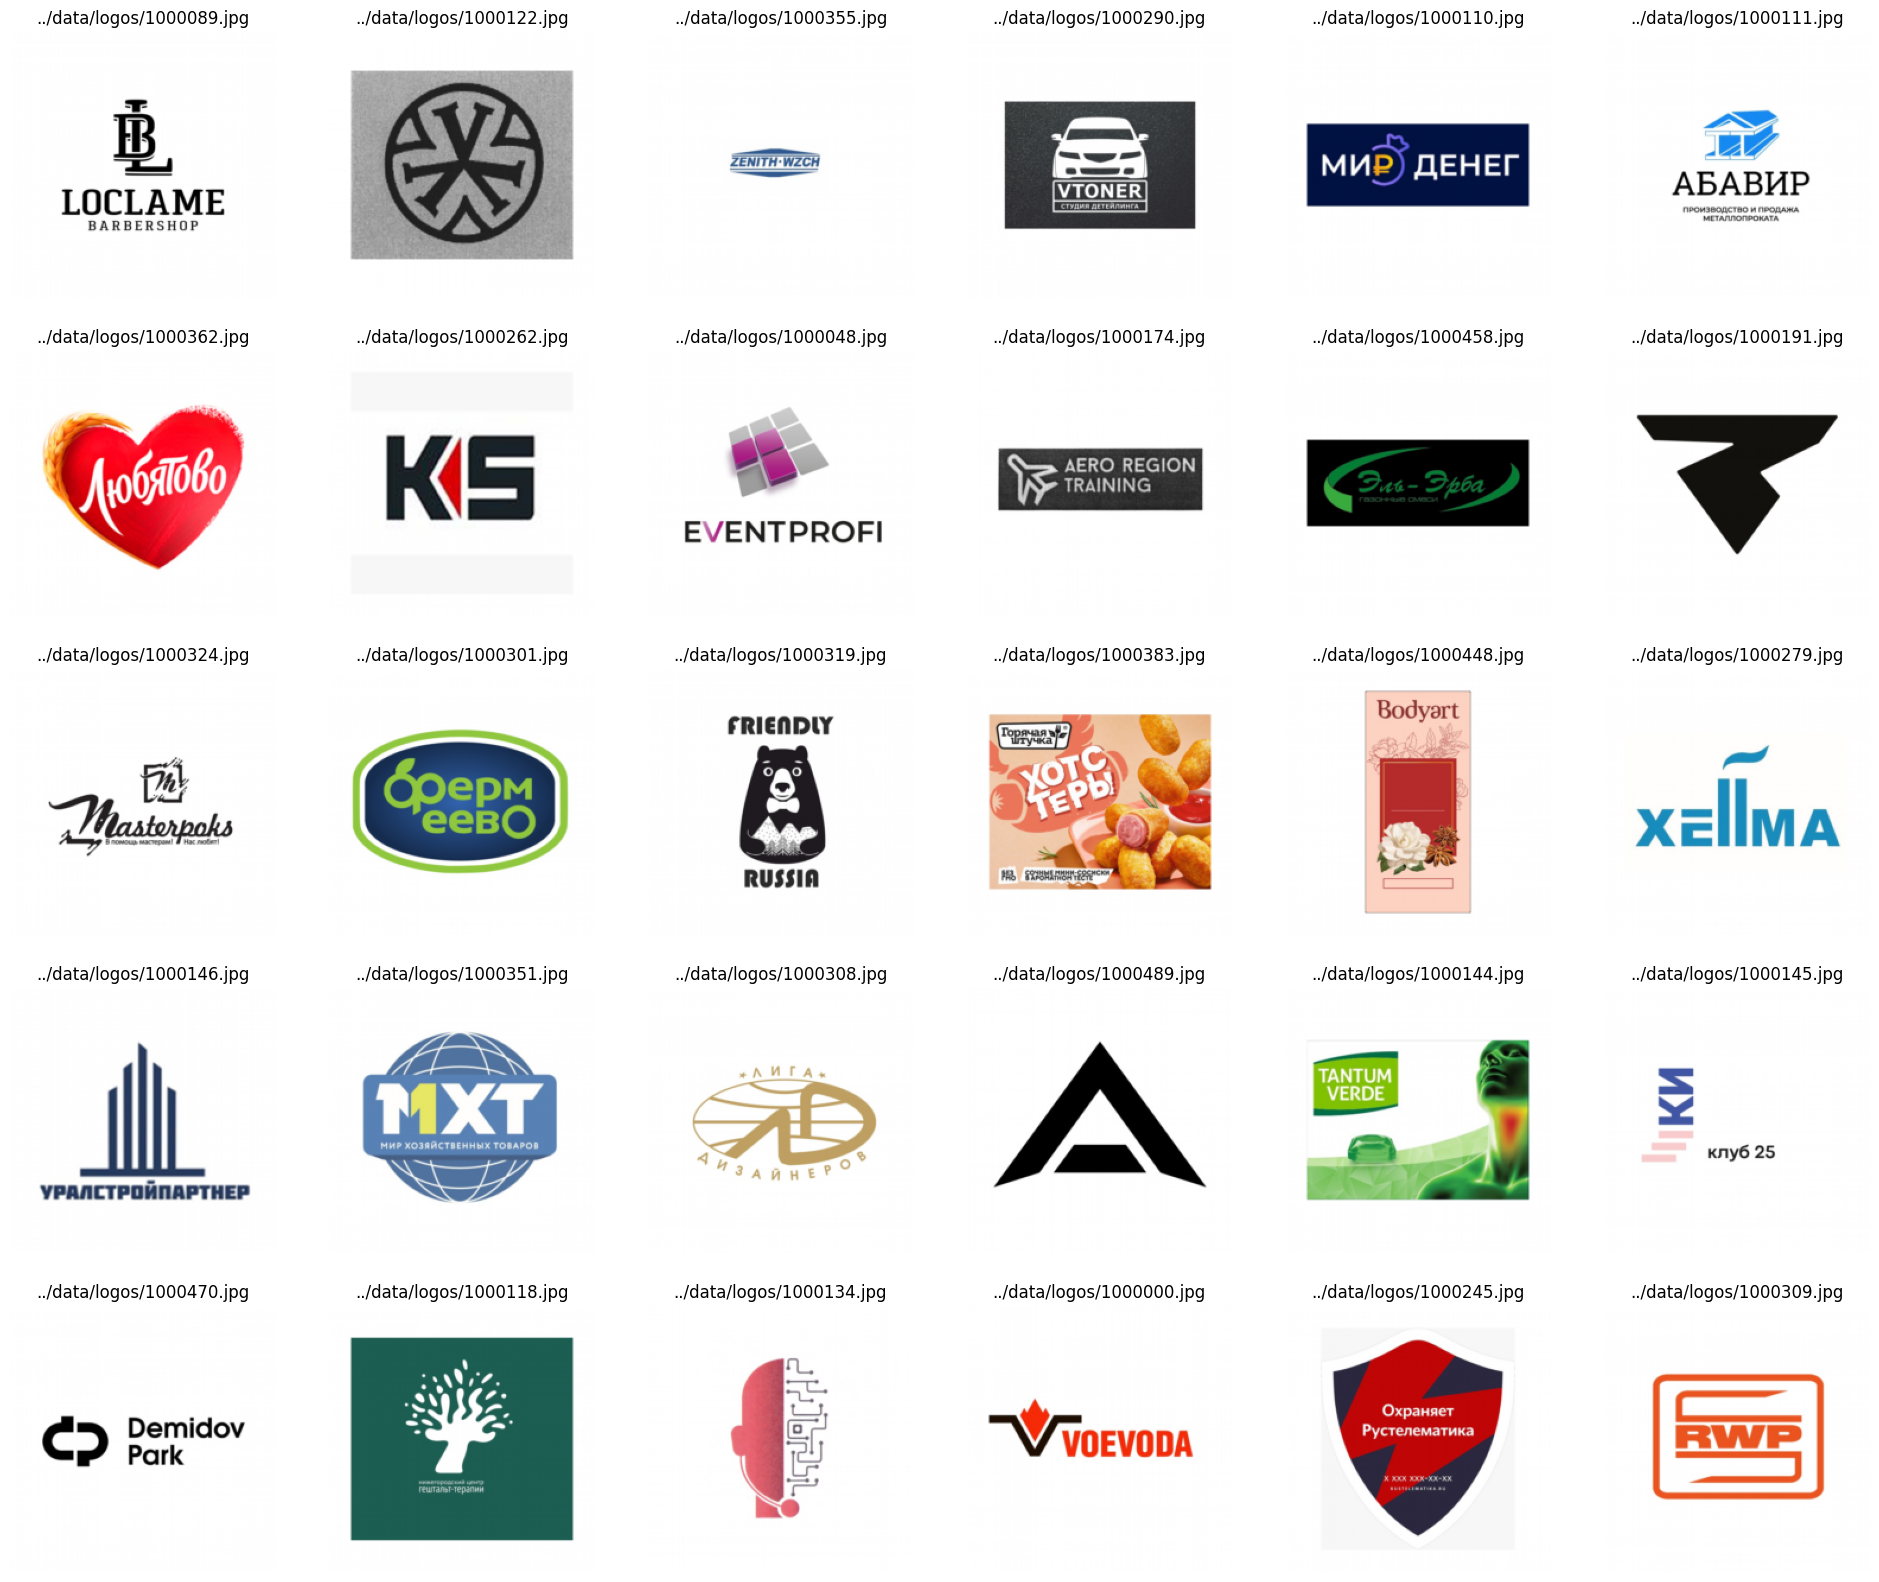

In [7]:
w, h = 6, 5
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

images = load_paths(images_path, '../data/logos_post.csv')

image_paths = []
np.random.shuffle(images)
image_paths.extend(images)

for i, (img_path, ax) in enumerate(zip(image_paths, axs.flatten())):
    img = load_image(img_path)

    ax.imshow(img.transpose(0,1).transpose(1,2))
    ax.set_title(img_path)
    ax.set_axis_off()

plt.show()

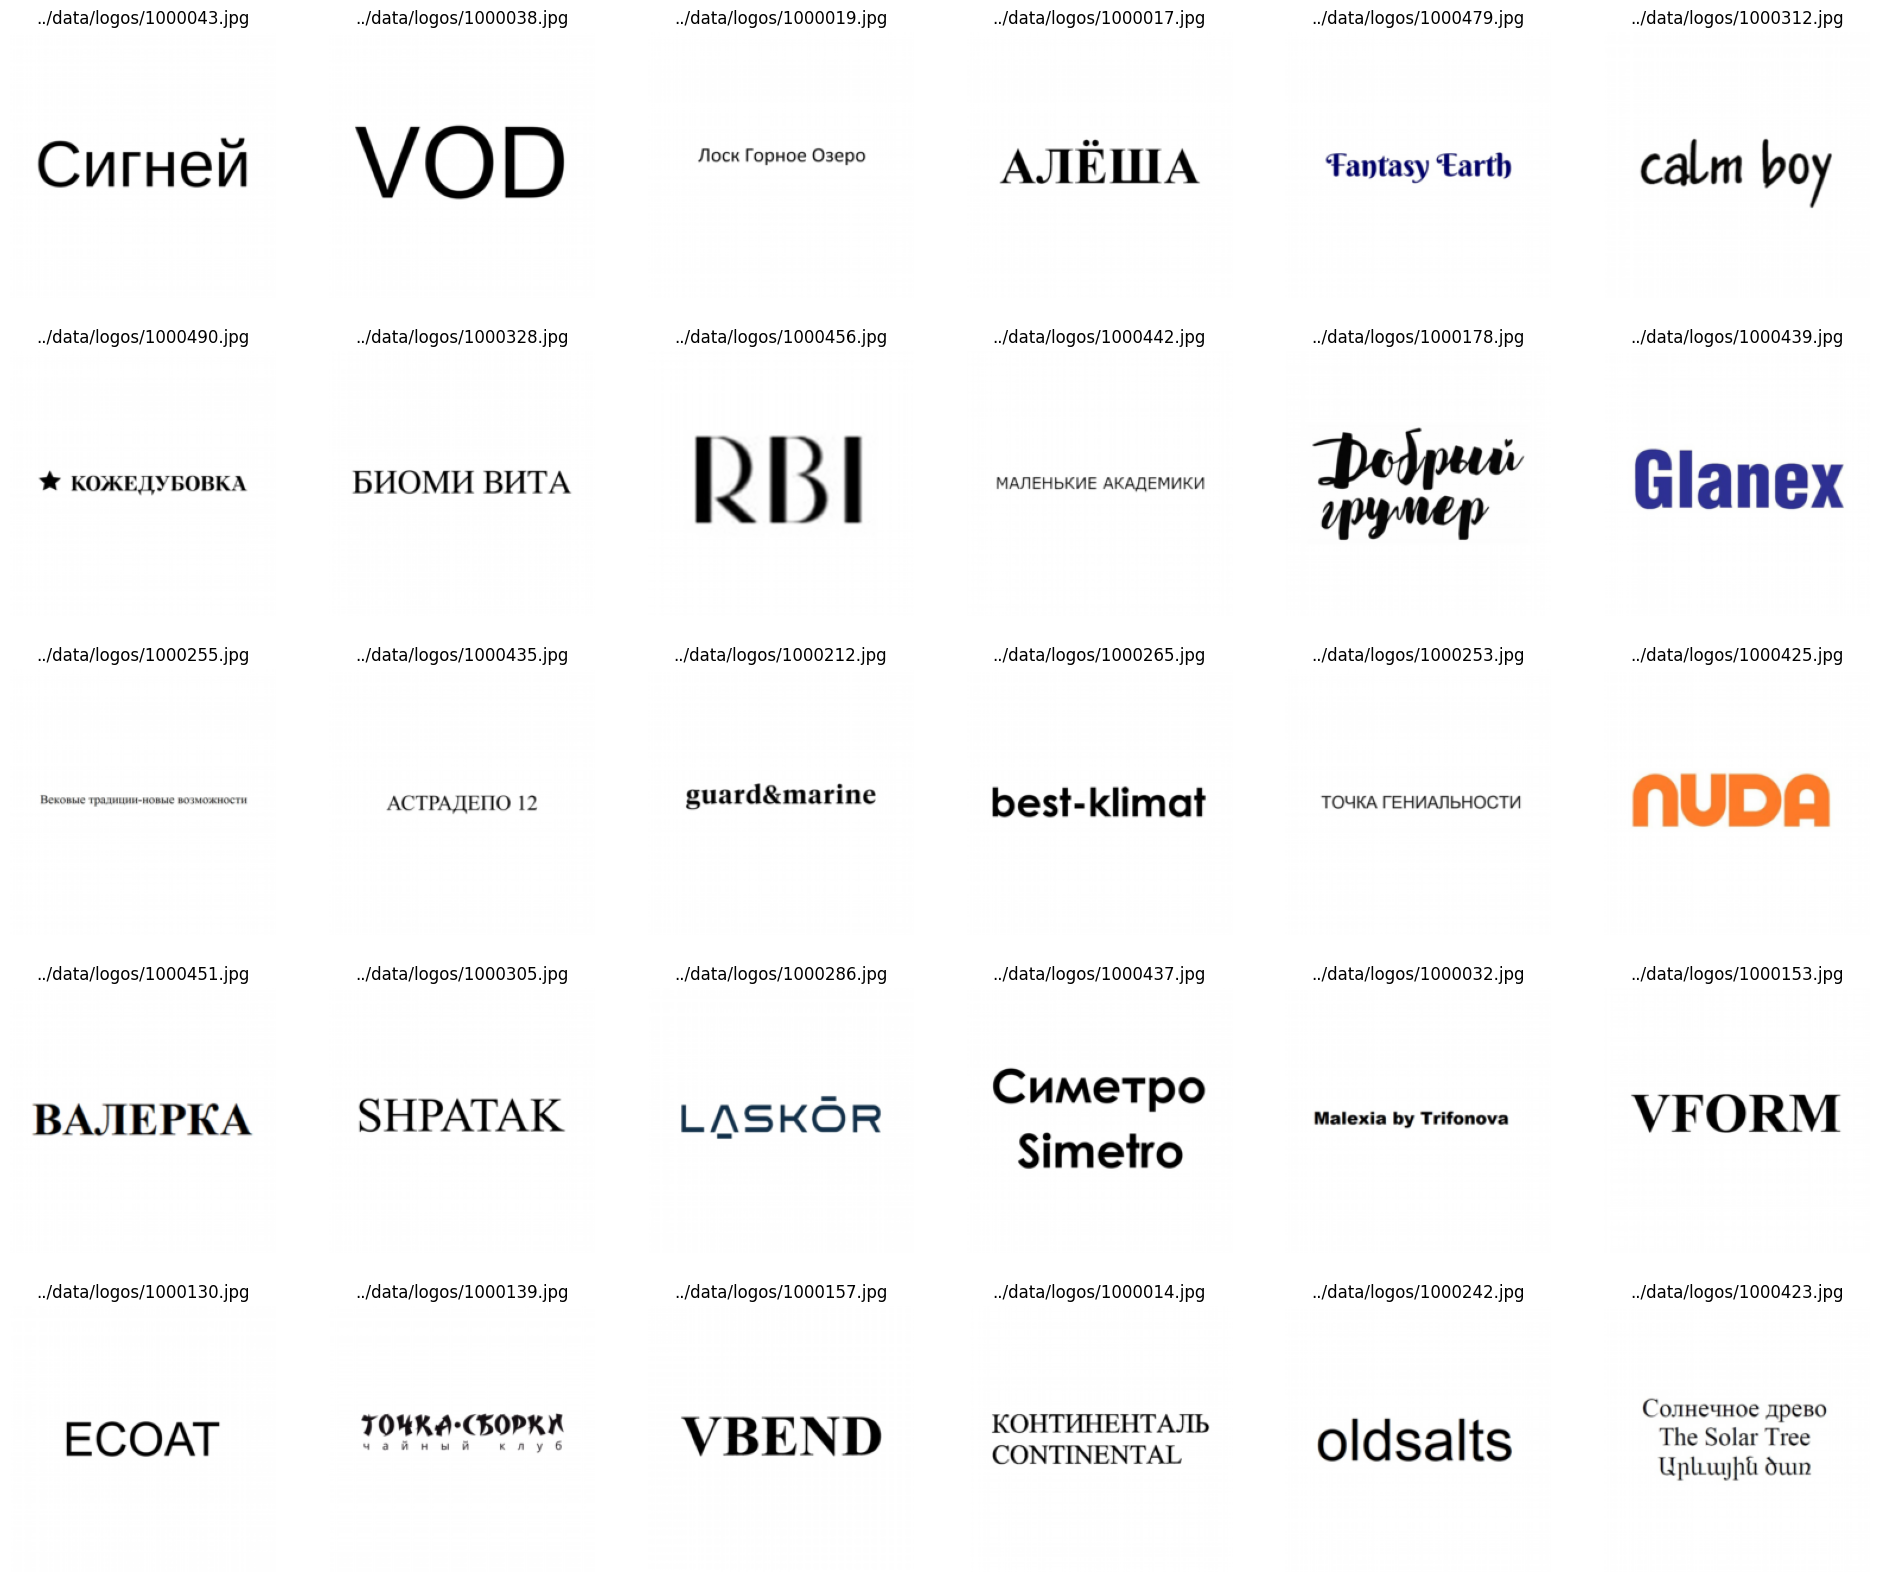

In [8]:
w, h = 6, 5
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

images = load_paths(images_path, '../data/text_post.csv')

image_paths = []
np.random.shuffle(images)
image_paths.extend(images)

for i, (img_path, ax) in enumerate(zip(image_paths, axs.flatten())):
    img = load_image(img_path)

    ax.imshow(img.transpose(0,1).transpose(1,2))
    ax.set_title(img_path)
    ax.set_axis_off()

plt.show()

In [9]:
class LogosDataset(Dataset):
    def __init__(self, root_dir, list_path, frames_limit=None, transform=None):
        self.root = root_dir
        self.transform = transform

        self.images = []

        images = load_paths(root_dir, list_path)
        image_paths = []

        if frames_limit is None:
            image_paths = images
        else:
            np.random.shuffle(images)
            image_paths.extend(images[:frames_limit])

        self.images.extend(image_paths)

        print(f'loaded {len(self.images)} paths')

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = read_image(img_path)
        if self.transform:
            image = self.transform(image)
        return image, img_path

In [10]:
def data_loader(data_dir, list_path, batch_size, frames_limit=None, shuffle=True, test=False):
    transform = image_transform(test)
    dataset = LogosDataset(data_dir, list_path, frames_limit, transform)

    indices = list(range(len(dataset)))
    if shuffle:
        np.random.shuffle(indices)

    sampler = SubsetRandomSampler(indices)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=sampler)
    return loader

In [11]:
logos_loader_train = data_loader('../data/logos', '../data/logos_train.csv', 16)
logos_loader_valid = data_loader('../data/logos', '../data/logos_valid.csv', 16)
text_loader_train = data_loader('../data/logos', '../data/text_train.csv', 16)
text_loader_valid = data_loader('../data/logos', '../data/text_valid.csv', 16)
all_loader = data_loader('../data/logos', None, 64, frames_limit=1000)

loaded 197 paths
loaded 50 paths
loaded 189 paths
loaded 48 paths
loaded 1000 paths


In [12]:
model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad = False
#for param in model.classifier[6].parameters():
#    param.requires_grad = True
model.classifier.append(nn.Linear(1000, 2)) # 2 classes: text, logo
model.classifier.append(nn.Sigmoid())
model = model.to(device)
model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

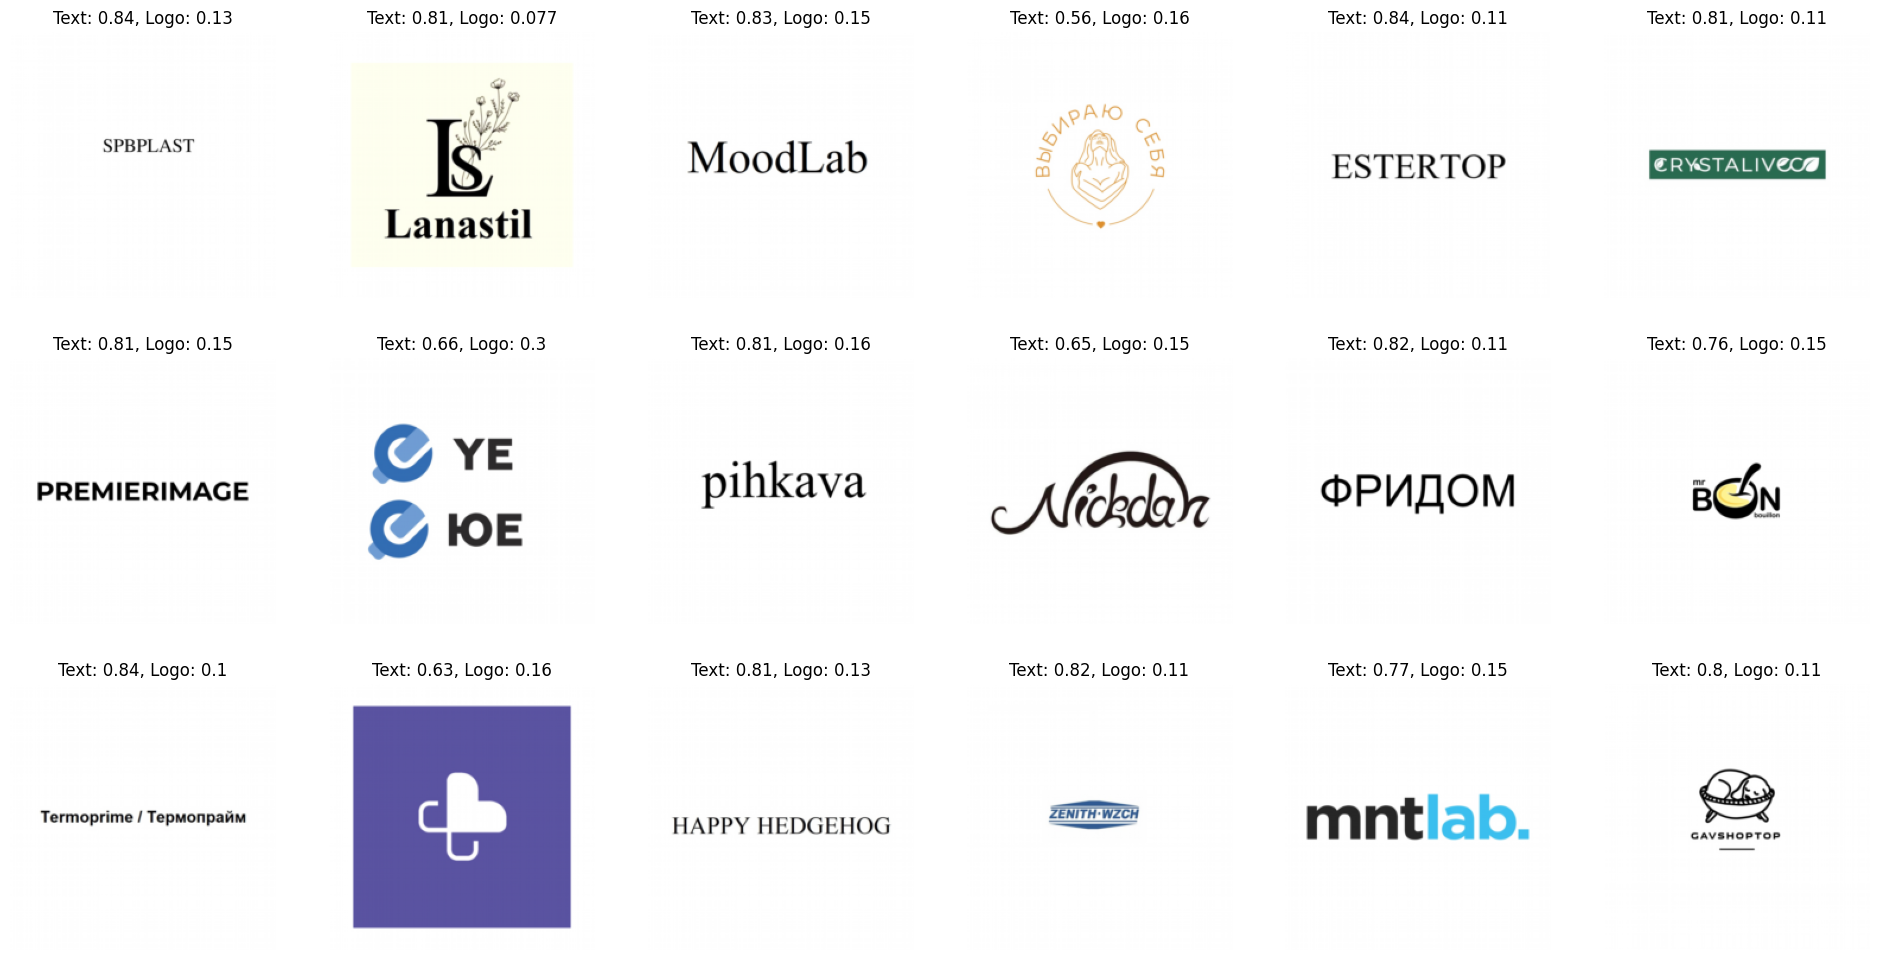

In [13]:
# Test base model

w, h = 6, 3
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

logo_paths = np.array(load_paths(images_path, '../data/logos_all.csv'))
np.random.shuffle(logo_paths)
text_paths = np.array(load_paths(images_path, '../data/text_all.csv'))
np.random.shuffle(text_paths)

model.eval()
for i, ax in enumerate(axs.flatten()):
    img_path = ''
    if i % 2 == 0:
        img_path = text_paths[i // 2]
    else:
        img_path = logo_paths[i // 2 + 1]
    img = load_image(img_path)
    
    encoded = model(img.unsqueeze(0).to(device)).detach().cpu().numpy().flatten()
    c_text = encoded[0]
    c_logo = encoded[1]

    ax.set_title(f'Text: {c_text:.2}, Logo: {c_logo:.2}')
    ax.set_axis_off()
    ax.imshow(img.transpose(0,1).transpose(1,2))

    img = load_image(img_path)

    ax.imshow(img.transpose(0,1).transpose(1,2))
    ax.set_axis_off()

plt.show()

cuda
Epoch 1/10


100%|██████████| 13/13 [00:09<00:00,  1.37it/s]


Epoch 2/10


100%|██████████| 13/13 [00:08<00:00,  1.45it/s]


Epoch 3/10


...

100%|██████████| 13/13 [00:09<00:00,  1.31it/s]


Epoch 9/10


100%|██████████| 13/13 [00:09<00:00,  1.33it/s]


Epoch 10/10


100%|██████████| 13/13 [00:09<00:00,  1.33it/s]


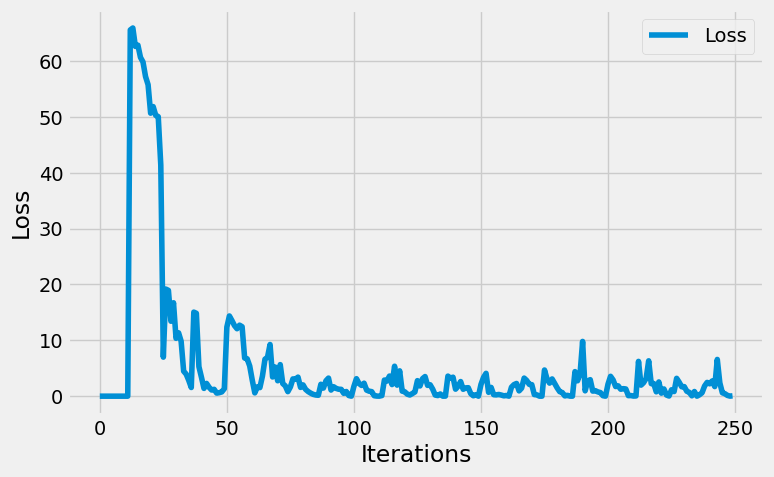

In [16]:
gc.collect()
torch.cuda.empty_cache()

loss_function = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0025, weight_decay=1e-8)

epochs = 10
losses = []

print(device)
model.to(device)
model.train()

# Training
for epoch in range(epochs):
    print(f'Epoch {epoch + 1}/{epochs}')
    for images, image_paths in tqdm(text_loader_train):
        label = torch.tensor([[1.0, 0.0]]).tile([images.shape[0], 1]).to(device)

        images = images.to(device)
        encoded = model(images)

        loss = loss_function(encoded, label)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    for images, image_paths in tqdm(logos_loader_train):
        label = torch.tensor([0.0, 1.0]).tile([images.shape[0], 1]).to(device)

        images = images.to(device)
        encoded = model(images)

        loss = loss_function(encoded, label)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

gc.collect()
torch.cuda.empty_cache()

model.eval()
save_model(model, '../models/text_detect.safetensors')
plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(losses, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

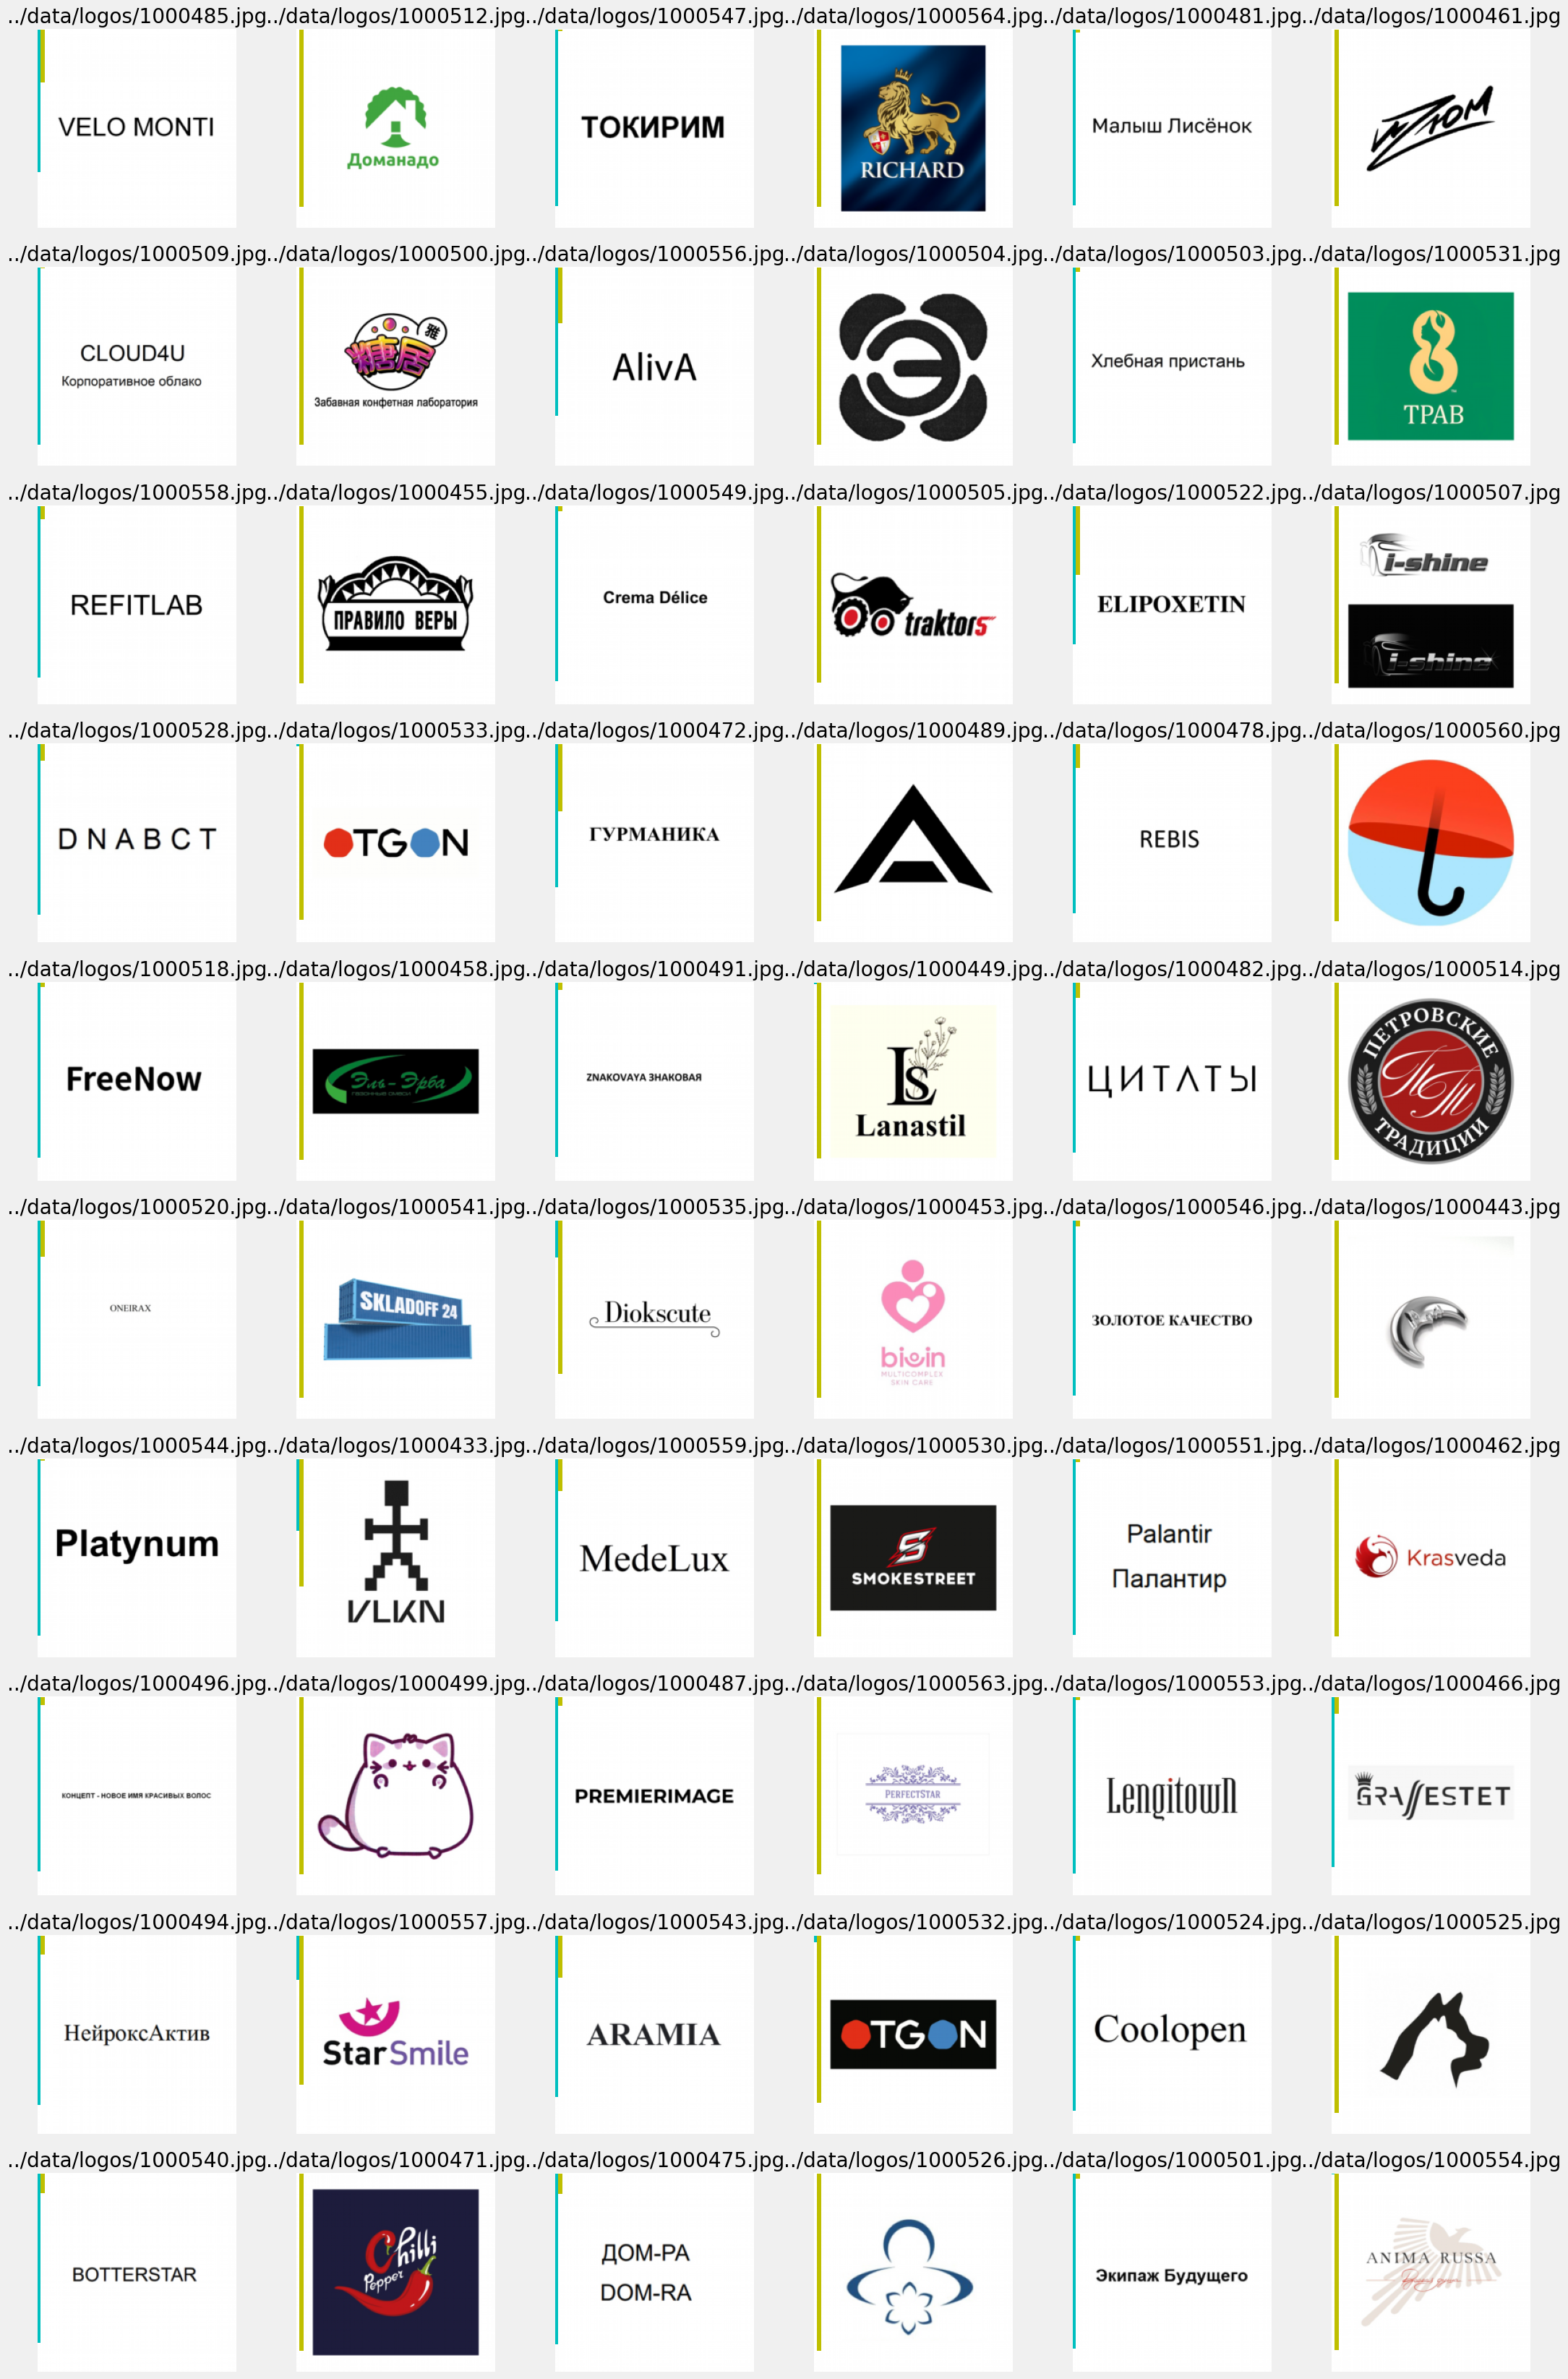

In [17]:
w, h = 6, 10
_, axs = plt.subplots(h, w, figsize=(w * 4, h * 4))

logo_paths = np.array(load_paths(images_path, '../data/logos_valid.csv'))
np.random.shuffle(logo_paths)
text_paths = np.array(load_paths(images_path, '../data/text_valid.csv'))
np.random.shuffle(text_paths)

model.eval()
for i, ax in enumerate(axs.flatten()):
    img_path = ''
    if i % 2 == 0:
        img_path = text_paths[i // 2]
    else:
        img_path = logo_paths[i // 2 + 1]
    img = load_image(img_path)
    
    encoded = model(img.unsqueeze(0).to(device)).detach().cpu().numpy().flatten()
    c_text = encoded[0]
    c_logo = encoded[1]

    ax.set_title(img_path)
    ax.set_axis_off()
    ax.imshow(img.transpose(0,1).transpose(1,2))
    ax.bar(0, c_text * 200, width=5, color='c')
    ax.bar(5, c_logo * 200, width=5, color='y')

    img = load_image(img_path)

    ax.imshow(img.transpose(0,1).transpose(1,2))
    ax.set_axis_off()

plt.show()

In [18]:
def generate_embeddings(model):
    model = model.to(device)
    embeddings = torch.tensor([]).to(device)
    all_paths = []
    for images, paths in tqdm(all_loader):
        encoding = model(images.to(device)).detach()
        embeddings = torch.cat((embeddings, encoding))
        all_paths += paths
    return embeddings, all_paths

In [19]:
classification, classification_path = generate_embeddings(model)

torch.save(classification, '../models/text_detect.pt')
pd.DataFrame(classification_path).to_csv('../models/text_detect.csv', header=None, index=False)

classification

  0%|          | 0/16 [00:00<?, ?it/s]

100%|██████████| 16/16 [00:47<00:00,  2.98s/it]


tensor([[9.7755e-07, 1.0000e+00],
        [8.0456e-08, 1.0000e+00],
        [1.5994e-03, 9.9822e-01],
        ...,
        [2.6934e-01, 8.5783e-01],
        [9.9738e-01, 9.9976e-03],
        [4.9399e-07, 1.0000e+00]], device='cuda:0')